In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

#Set a default seaborn style
sns.set_style('whitegrid')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score, classification_report, precision_recall_fscore_support
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance

import pickle

In [4]:
#read in data
data = pd.read_csv('/home/amybirdee/hobby_projects/attachment_style_prediction/attachment_survey_with_labels.csv')

In [5]:
#drop unwanted columns
data = data.drop('Unnamed: 0', axis = 1)

In [6]:
data.head()

,__row_id,age,gender,relationship_status,parenting_style,conflict_response,comfort_with_intimacy,fear_of_abandonment,trust_in_others,openness_in_relationships,social_support_perception,relationship_satisfaction,mental_health_status,attachment_style_label,relationship_reflection
0,0,45,Male,Single,Authoritative,Compromising,3,1,2,5,5,5,Stable,Dismissive Avoidant,I am single by choice these days and oddly con...
1,1,31,Female,In a relationship,Authoritative,Passive,2,2,4,1,1,5,Mild Issues,Fearful Avoidant,Being in a steady relationship feels safe and ...
2,2,24,Prefer not to say,In a relationship,Permissive,Compromising,4,1,4,1,4,4,Stable,Secure,I am comfortable being close and enjoy the eas...
3,3,37,Male,Single,NaN,Avoidant,1,5,1,2,5,3,Mild Issues,Fearful Avoidant,I find myself catching between wanting connect...
4,4,35,Female,In a relationship,Permissive,Assertive,3,1,5,2,2,5,Mild Issues,Secure,I feel lucky in my partnership and approach di...


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   __row_id                   3000 non-null   int64 
 1   age                        3000 non-null   int64 
 2   gender                     3000 non-null   object
 3   relationship_status        3000 non-null   object
 4   parenting_style            2415 non-null   object
 5   conflict_response          3000 non-null   object
 6   comfort_with_intimacy      3000 non-null   int64 
 7   fear_of_abandonment        3000 non-null   int64 
 8   trust_in_others            3000 non-null   int64 
 9   openness_in_relationships  3000 non-null   int64 
 10  social_support_perception  3000 non-null   int64 
 11  relationship_satisfaction  3000 non-null   int64 
 12  mental_health_status       3000 non-null   object
 13  attachment_style_label     3000 non-null   object
 14  relation

In [8]:
#fill missing data in parenting column
data['parenting_style'] = data['parenting_style'].fillna('N/A')

# Data Preparation for Model

In [9]:
#create a new version of the dataframe for modelling
model_data = data.copy()

In [10]:
#convert target column into numeric field

label_map = {
    'Anxious': 0,
    'Dismissive Avoidant': 1,
    'Fearful Avoidant': 2,
    'Secure': 3
}

model_data['attachment_style_label'] = model_data['attachment_style_label'].map(label_map).astype(int)

In [11]:
#separate feature and target variables
X = model_data.drop(columns = 'attachment_style_label')
y = model_data['attachment_style_label']

In [12]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [13]:
#check size of each dataset
print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)

X_train shape:  (2400, 14)
X_test shape:  (600, 14)
y_train shape:  (2400,)
y_test shape:  (600,)


In [14]:
#check counts and proportions for each class in test set

count_class_0, count_class_1, count_class_2, count_class_3 = y_test.value_counts().sort_index()
prop_class_0, prop_class_1, prop_class_2, prop_class_3 = round(y_test.value_counts(normalize = True), 2).sort_index()

print('Anxious Count: ', count_class_0) 
print('Anxious Proportion: ', prop_class_0)
print('')
print('Dismissive Avoidant Count: ', count_class_1) 
print('Dismissive Avoidant Proportion: ', prop_class_1)
print('')
print('Fearful Avoidant Count: ', count_class_2) 
print('Fearful Avoidant Proportion: ', prop_class_2)
print('')
print('Secure Count: ', count_class_3) 
print('Secure Proportion: ', prop_class_3)

Anxious Count:  163
Anxious Proportion:  0.27

Dismissive Avoidant Count:  134
Dismissive Avoidant Proportion:  0.22

Fearful Avoidant Count:  186
Fearful Avoidant Proportion:  0.31

Secure Count:  117
Secure Proportion:  0.2


In [15]:
#split text and structure columns
X_train_text = X_train['relationship_reflection']
X_test_text = X_test['relationship_reflection']

X_train_structured = X_train.drop(columns = ['relationship_reflection', '__row_id'])
X_test_structured = X_test.drop(columns = ['relationship_reflection', '__row_id'])

In [16]:
#define the embedding model for the text data. We will use sentence-transformers/all-MiniLM-L6-v2 because it's lightweight
#and fast and designed for sentence / paragraph embeddings

embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

#apply the embedding model on X_train_text and X_test_text
train_text_embeddings = embedding_model.encode(X_train_text.tolist(), batch_size = 32, show_progress_bar = True)
test_text_embeddings = embedding_model.encode(X_test_text.to_list(), batch_size = 32, show_progress_bar = True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/75 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

In [17]:
#apply the embeddings has created an array - checking shapes
print('Train embeddings shape: ', train_text_embeddings.shape)
print('Test embeddings shape: ', test_text_embeddings.shape)

Train embeddings shape:  (2400, 384)
Test embeddings shape:  (600, 384)


In [18]:
#create embedding column names as we need to convert the array back to a dataframe
embedding_columns = [f'embedding_{i}' for i in range(train_text_embeddings.shape[1])]

#create the dataframes
X_train_embeddings = pd.DataFrame(train_text_embeddings, columns = embedding_columns, index = X_train.index)
X_test_embeddings = pd.DataFrame(test_text_embeddings, columns = embedding_columns, index = X_test.index)

In [19]:
#define numerical and categorical columns in X_train_structured
num_cols = X_train_structured.select_dtypes(include = ['int64', 'float64']).columns
cat_cols = X_train_structured.select_dtypes(include = ['object']).columns

#create a structured processer for the model. Passthrough means keep the numeric columns unchanged
structured_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_cols)
    ]
)

In [20]:
#apply the preprocessor on the structured data
train_structured_processed = structured_preprocessor.fit_transform(X_train_structured)
test_structured_processed = structured_preprocessor.transform(X_test_structured)

In [21]:
#checking shapes
print('Train structured shape: ', train_structured_processed.shape)
print('Test structured shape: ', test_structured_processed.shape)

Train structured shape:  (2400, 30)
Test structured shape:  (600, 30)


In [22]:
#preprocessing has created arrays. Get column names so we can conver to a dataframe
structured_columns = structured_preprocessor.get_feature_names_out()

#convert to dataframe
X_train_structured_df = pd.DataFrame(train_structured_processed, columns = structured_columns, index = X_train.index)
X_test_structured_df = pd.DataFrame(test_structured_processed, columns = structured_columns, index = X_test.index)

In [23]:
#combine the text and structured preprocessed dataframes
X_train_combined = pd.concat([X_train_structured_df, X_train_embeddings], axis = 1)
X_test_combined = pd.concat([X_test_structured_df, X_test_embeddings], axis = 1)

In [24]:
#checking shapes
print('X_train_combined shape: ', X_train_combined.shape)
print('X_test_combined shape: ', X_test_combined.shape)

X_train_combined shape:  (2400, 414)
X_test_combined shape:  (600, 414)


In [25]:
#check for NAN columns
print(X_train_combined.isna().sum().sum())
print(X_test_combined.isna().sum().sum())

0
0


In [26]:
X_train_combined.head()

,num__age,num__comfort_with_intimacy,num__fear_of_abandonment,num__trust_in_others,num__openness_in_relationships,num__social_support_perception,num__relationship_satisfaction,cat__gender_Female,cat__gender_Male,cat__gender_Non-binary,...,embedding_374,embedding_375,embedding_376,embedding_377,embedding_378,embedding_379,embedding_380,embedding_381,embedding_382,embedding_383
213,32.0,2.0,2.0,5.0,3.0,4.0,5.0,0.0,1.0,0.0,...,-0.058656,0.015631,-0.016670,0.083829,0.041881,0.025637,0.032879,0.047690,-0.069117,-0.079832
1223,44.0,3.0,3.0,5.0,3.0,4.0,1.0,0.0,1.0,0.0,...,-0.021445,-0.035358,-0.015342,0.056407,-0.008196,-0.003798,-0.025309,-0.031796,-0.057728,-0.061556
2885,36.0,5.0,5.0,1.0,4.0,3.0,1.0,0.0,1.0,0.0,...,-0.063258,-0.006975,0.019422,0.097865,0.017824,0.039227,0.017068,-0.042800,-0.040971,-0.058041
2348,35.0,1.0,3.0,1.0,3.0,5.0,2.0,0.0,0.0,1.0,...,-0.060675,0.026497,0.006716,0.092151,0.033003,-0.006916,-0.036970,-0.027884,-0.047610,-0.034053
266,42.0,5.0,5.0,1.0,1.0,3.0,2.0,1.0,0.0,0.0,...,-0.034052,0.003842,0.004055,0.049182,0.008705,0.042335,0.057352,0.003472,-0.054932,-0.027226


# Model Training

We will train three models in this section:

  1) Structured data only
  2) Embeddings data only
  3) Structured + embeddings data

This will allow us to see a fresh baseline on the current split of data, tell us how much signal the generated text carries by itself and then compare with how the model performs when structured and text data are combined.

A Random Forest and XG Boost model will be trained in all three cases because these performed best during earlier model selection.

In [27]:
#define models to run

experiments = [
    {
        'name': 'rf_structured',
        'model': RandomForestClassifier(random_state = 42),
        'X_train': X_train_structured_df,
        'X_test': X_test_structured_df
    },
    {
        'name': 'rf_embeddings',
        'model': RandomForestClassifier(random_state = 42),
        'X_train': X_train_embeddings,
        'X_test': X_test_embeddings
    },
    {
        'name': 'rf_combined',
        'model': RandomForestClassifier(random_state = 42),
        'X_train': X_train_combined,
        'X_test': X_test_combined
    },
    {
        'name': 'xgb_structured',
        'model': XGBClassifier(random_state = 42, eval_metric = 'mlogloss'),
        'X_train': X_train_structured_df,
        'X_test': X_test_structured_df
    },
    {
        'name': 'xgb_embeddings',
        'model': XGBClassifier(random_state = 42, eval_metric = 'mlogloss'),
        'X_train': X_train_embeddings,
        'X_test': X_test_embeddings
    },
    {
        'name': 'xgb_combined',
        'model': XGBClassifier(random_state = 42, eval_metric = 'mlogloss'),
        'X_train': X_train_combined,
        'X_test': X_test_combined
    }
]



Confusion matrix: rf_structured

[[ 94  26  20  23]
 [ 16  84  14  20]
 [ 21  20 117  28]
 [ 23  20  18  56]]


Classification report: rf_structured

              precision    recall  f1-score   support

           0       0.61      0.58      0.59       163
           1       0.56      0.63      0.59       134
           2       0.69      0.63      0.66       186
           3       0.44      0.48      0.46       117

    accuracy                           0.58       600
   macro avg       0.58      0.58      0.58       600
weighted avg       0.59      0.58      0.59       600

AUC (multiclass, macro) rf_structured: 0.83551


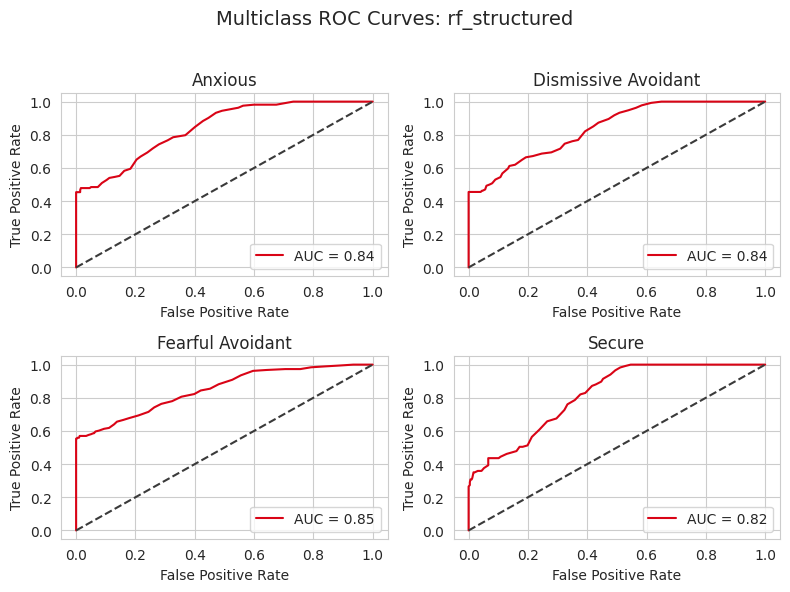



Confusion matrix: rf_embeddings

[[ 55  21  67  20]
 [ 39  18  63  14]
 [ 59  15 103   9]
 [ 26  25  57   9]]


Classification report: rf_embeddings

              precision    recall  f1-score   support

           0       0.31      0.34      0.32       163
           1       0.23      0.13      0.17       134
           2       0.36      0.55      0.43       186
           3       0.17      0.08      0.11       117

    accuracy                           0.31       600
   macro avg       0.27      0.28      0.26       600
weighted avg       0.28      0.31      0.28       600

AUC (multiclass, macro) rf_embeddings: 0.57995


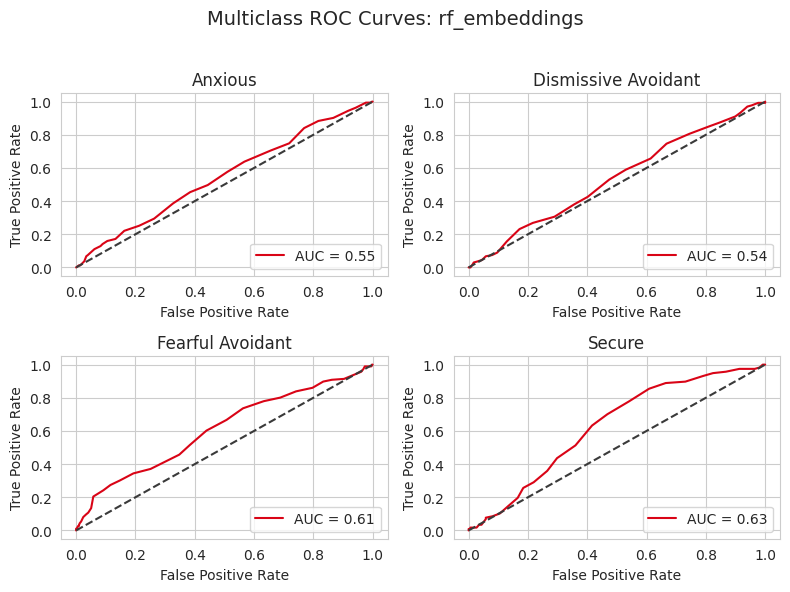



Confusion matrix: rf_combined

[[ 94  23  31  15]
 [ 28  67  31   8]
 [ 26  15 128  17]
 [ 38  22  24  33]]


Classification report: rf_combined

              precision    recall  f1-score   support

           0       0.51      0.58      0.54       163
           1       0.53      0.50      0.51       134
           2       0.60      0.69      0.64       186
           3       0.45      0.28      0.35       117

    accuracy                           0.54       600
   macro avg       0.52      0.51      0.51       600
weighted avg       0.53      0.54      0.53       600

AUC (multiclass, macro) rf_combined: 0.77234


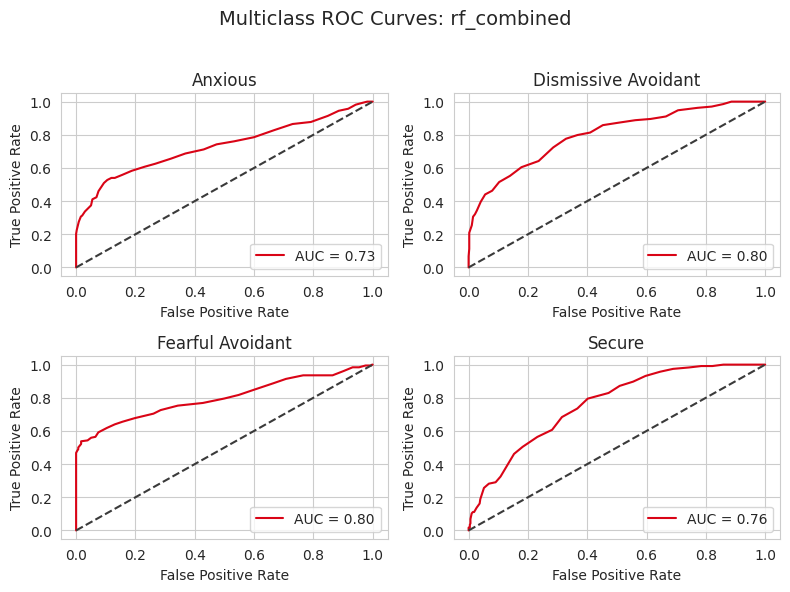



Confusion matrix: xgb_structured

[[ 90  28  27  18]
 [ 13  77  18  26]
 [ 31  23 114  18]
 [ 14  29  16  58]]


Classification report: xgb_structured

              precision    recall  f1-score   support

           0       0.61      0.55      0.58       163
           1       0.49      0.57      0.53       134
           2       0.65      0.61      0.63       186
           3       0.48      0.50      0.49       117

    accuracy                           0.56       600
   macro avg       0.56      0.56      0.56       600
weighted avg       0.57      0.56      0.57       600

AUC (multiclass, macro) xgb_structured: 0.83461


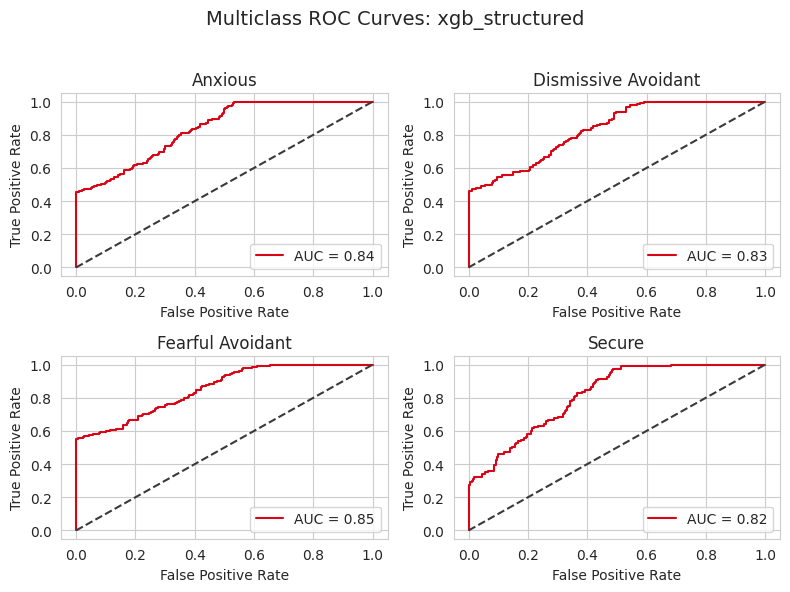



Confusion matrix: xgb_embeddings

[[51 29 62 21]
 [41 29 40 24]
 [58 28 89 11]
 [34 26 37 20]]


Classification report: xgb_embeddings

              precision    recall  f1-score   support

           0       0.28      0.31      0.29       163
           1       0.26      0.22      0.24       134
           2       0.39      0.48      0.43       186
           3       0.26      0.17      0.21       117

    accuracy                           0.32       600
   macro avg       0.30      0.29      0.29       600
weighted avg       0.31      0.32      0.31       600

AUC (multiclass, macro) xgb_embeddings: 0.56607


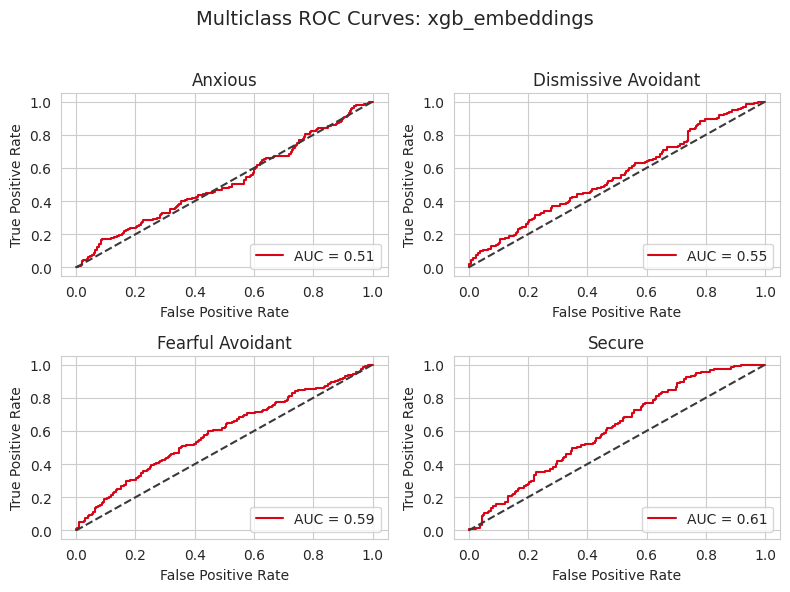



Confusion matrix: xgb_combined

[[100  25  16  22]
 [ 24  82  13  15]
 [ 22  22 126  16]
 [ 27  16  18  56]]


Classification report: xgb_combined

              precision    recall  f1-score   support

           0       0.58      0.61      0.60       163
           1       0.57      0.61      0.59       134
           2       0.73      0.68      0.70       186
           3       0.51      0.48      0.50       117

    accuracy                           0.61       600
   macro avg       0.60      0.60      0.60       600
weighted avg       0.61      0.61      0.61       600

AUC (multiclass, macro) xgb_combined: 0.84858


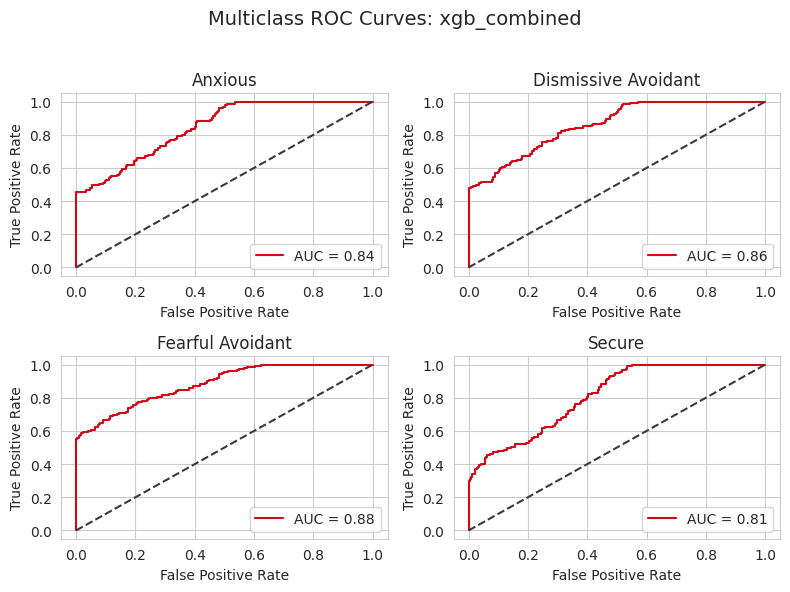

In [28]:
#loop iterates over each model, fits the data, creates predictions and outputs the results

class_labels = {
    0: 'Anxious',
    1: 'Dismissive Avoidant',
    2: 'Fearful Avoidant',
    3: 'Secure'}

for experiment in experiments:
    name = experiment['name']
    model = experiment['model']
    X_train_current = experiment['X_train']
    X_test_current = experiment['X_test']

    model.fit(X_train_current, y_train)

    y_pred = model.predict(X_test_current)
    y_prob = model.predict_proba(X_test_current)

    #binarize target so we can create a single AUC score
    classes = sorted(y.unique())
    y_test_bin = label_binarize(y_test, classes = classes)

    #compute AUC
    auc_score = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class = 'ovr',   
    average = 'macro')

    print('\n')
    print('\033[1m' + f'Confusion matrix: {name}\n')
    print(confusion_matrix(y_test, y_pred))
    
    print('\n')
    print('\033[1m' + f'Classification report: {name}\n')
    print(classification_report(y_test, y_pred))
    
    #this AUC/ROC score lets us compare model performance between models. It treats each class as 'one vs rest'
    #and averages performance across all classes giving us one comparable number per model
    print(f"AUC (multiclass, macro) {name}: {round(auc_score, 5)}")

    # we will also create charts showing the ROC curve but this version compares how well the model 
    #classifies each of the four classes. It gives one ROC curve per attachment style letting us see 
    #which class is harder to predict
    
    # create 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize = (8, 6))
    axes = axes.flatten()

    for i, class_label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        
        ax = axes[i]
        ax.plot(fpr, tpr, label = f'AUC = {roc_auc:.2f}', color = '#D90416')
        ax.plot([0, 1], [0, 1], linestyle = '--', color = '#3A3A3A')
        
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(class_labels[class_label])
        ax.legend(loc = 'lower right')
        
    fig.suptitle(f'Multiclass ROC Curves: {name}', fontsize = 14)
    plt.tight_layout(rect = [0, 0, 1, 0.96])
    plt.show()

# Insights From Model Training

**The Random Forest and XGBoost models both performed strongly when trained on structured data alone, achieving similar levels of accuracy and AUC. The Random Forest model achieved a slightly higher baseline accuracy, while XGBoost produced a comparable AUC score, indicating that both models were effective at capturing the relationships within the structured features.**

**When embeddings were used in isolation, both models performed significantly worse, with accuracy dropping to approximately 30% and AUC scores close to random. This indicates that the generated text embeddings, when used alone, do not contain sufficient standalone signal to accurately predict attachment styles. This is expected given that the text was synthetically generated from the original structured features, meaning it does not introduce substantial new information but rather a transformed representation of existing inputs.**

**When combining structured data with embeddings, the models behaved differently. The Random Forest model showed a deterioration in performance compared to using structured data alone. This suggests that the high dimensionality of the embeddings introduced noise and diluted the signal from the structured features, which Random Forest was unable to effectively filter out due to its reliance on random feature sampling.**

**In contrast, the XGBoost model showed a modest improvement when embeddings were added to the structured data, achieving the best overall performance across all experiments. This suggests that XGBoost is better able to extract incremental signal from the embeddings by focusing on the most informative features during its sequential boosting process. The improvement, while not dramatic, indicates that the embeddings do contain some additional predictive value when combined with structured features.**

**Across all models, Fearful Avoidant (class 2) remained the easiest class to predict, with consistently higher precision, recall and AUC scores. Secure (class 3) continued to be the most challenging class overall, although there was some evidence that embeddings slightly improved its detection, suggesting that linguistic patterns captured in the text may provide additional signal for this class.**

**Overall, these results indicate that structured features remain the primary driver of model performance, while embeddings provide limited but meaningful incremental value when used in conjunction with more advanced models such as XGBoost.**

# Hyperparameter Tuning

In [29]:
#define the variables that will be tuned in the xgb model
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2, 3]
}

In [30]:
#define model
xgb = XGBClassifier(
    objective = 'multi:softprob', #multiclass classifier
    num_class = 4, #predict 4 classes
    random_state = 42,
    eval_metric = 'mlogloss',
    tree_method = 'hist' #this speeds up training by grouping continuous feature values into bins and evaluating splits at the bin 
#level rather than every unique value. Good for high-dimensional data such as embeddings.
)

#define cross validation 
cv = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)

#fit the models
xgb_tuned = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_grid,
    n_iter = 15,
    scoring = 'f1_macro', #use f1 Macro because this is a multi-class classification problem with mild imbalance
    cv = cv,
    verbose = 1,
    n_jobs = 1,
    random_state = 42
)

xgb_tuned.fit(X_train_combined, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,estimator,"XGBClassifier...oftprob', ...)"
,param_distributions,"{'colsample_bytree': [0.5, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,n_iter,15
,scoring,'f1_macro'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [31]:
#find the best parameters and best score
print('Best Parameters: ', xgb_tuned.best_params_)
print('')
print('Best Score: ', xgb_tuned.best_score_)

Best Parameters:  {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.7}

Best Score:  0.602500130307248


In [32]:
#put the best model into a variable
best_xgb = xgb_tuned.best_estimator_

#make predictions on test_set
y_pred_best = best_xgb.predict(X_test_combined)

# Evaluating Model on Test Set

Confusion matrix: Best XGB Model

[[ 99  27  17  20]
 [ 26  76  18  14]
 [ 31  21 123  11]
 [ 30  19  16  52]]


Classification report: Best XGB Model

              precision    recall  f1-score   support

           0       0.53      0.61      0.57       163
           1       0.53      0.57      0.55       134
           2       0.71      0.66      0.68       186
           3       0.54      0.44      0.49       117

    accuracy                           0.58       600
   macro avg       0.58      0.57      0.57       600
weighted avg       0.59      0.58      0.58       600



AUC (multiclass, macro) Best XGB Model: 0.84182


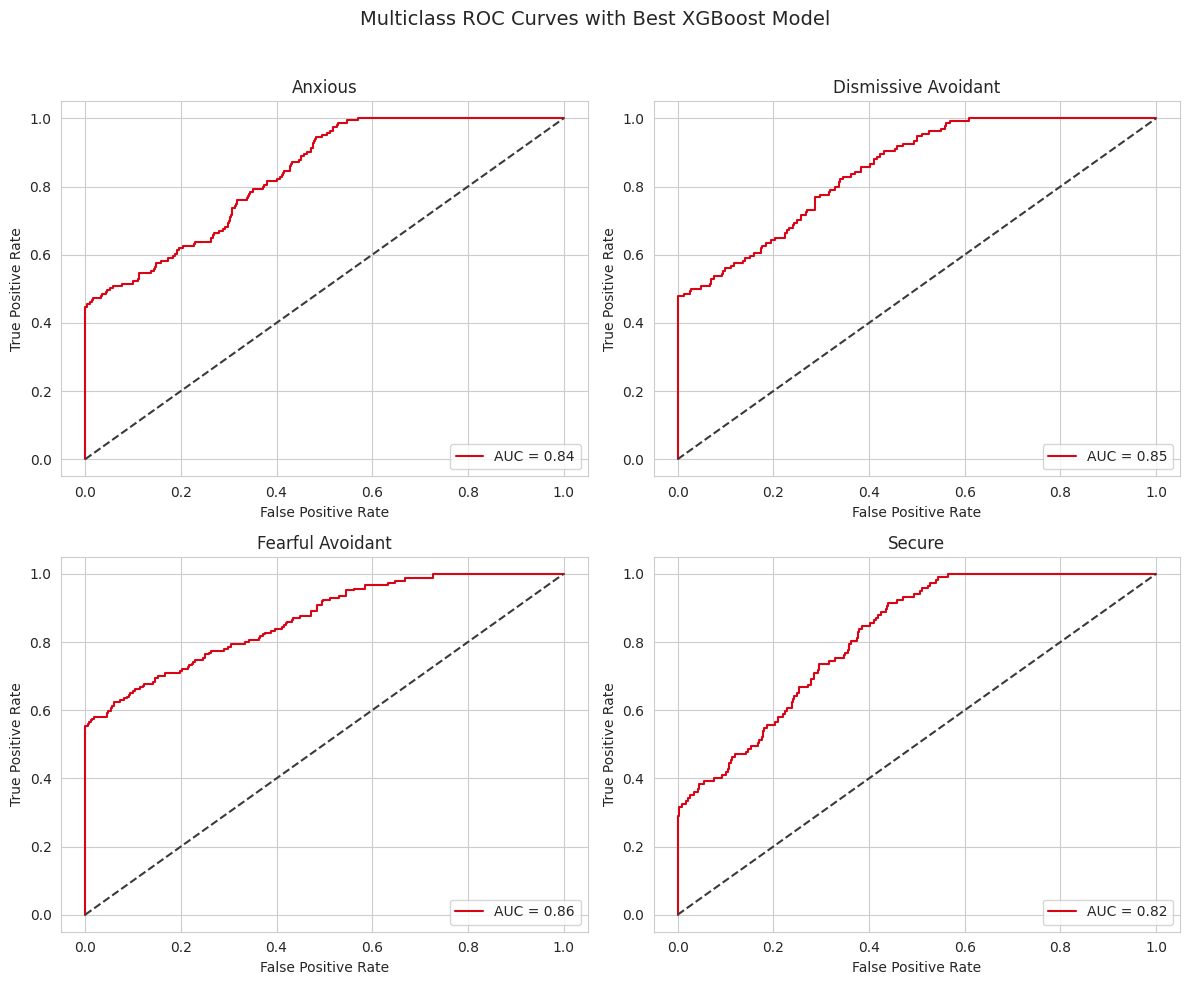

In [63]:
#print confusion matrix
print('\033[1m' + f'Confusion matrix: Best XGB Model\n')
print(confusion_matrix(y_test, y_pred_best))

#print classification report
print('\n')
print('\033[1m' + f'Classification report: Best XGB Model\n')
print(classification_report(y_test, y_pred_best))

#get predicted probabilities
y_prob = best_xgb.predict_proba(X_test_combined)

#binarize target
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes = classes)

#compute AUC
auc_score = roc_auc_score(y_test_bin, y_prob, multi_class = 'ovr', average = 'macro')

print('\n')
print(f"AUC (multiclass, macro) Best XGB Model: {round(auc_score, 5)}")

#print ROC curve
#create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
axes = axes.flatten()

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
        
    ax = axes[i]
    ax.plot(fpr, tpr, label = f'AUC = {roc_auc:.2f}', color = '#D90416')
    ax.plot([0, 1], [0, 1], linestyle = '--', color = '#3A3A3A')
        
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(class_labels[class_label])
    ax.legend(loc = 'lower right')

fig.suptitle(f'Multiclass ROC Curves with Best XGBoost Model', fontsize = 14)
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

In [64]:
#checking feature importance in the best model
feature_importance = best_xgb.feature_importances_

#convert to df
feature_importance_df = pd.DataFrame({'feature': X_train_combined.columns,
                                      'importance': feature_importance}).sort_values(by = 'importance', ascending = False)

In [65]:
#remove transformer prefixes
feature_importance_df['feature'] = (feature_importance_df['feature'].str.replace('num__', '', regex = False)\
    .str.replace('cat__', '', regex = False))

In [66]:
#recover original feature names for chart
feature_importance_df['original_feature'] = feature_importance_df['feature'].str.replace(r'_[A-Z].*$', '', regex = True)

In [67]:
#aggregate importances back to original feature level
grouped_importance = (feature_importance_df.groupby('original_feature', as_index = False)['importance'].sum().sort_values\
                      (by = 'importance', ascending = False))

In [68]:
#now looking at permutation importance - this tells us which features actually drive predictions. The regular model feature importance
#just tells you which features the model happened to split on. 
#Permutation importance measures how much the chosen scoring metric changes when each feature is shuffled. If there's a big drop 
#in performance, the model depended heavily on that feature
result = permutation_importance(
    best_xgb,
    X_test_combined,
    y_test,
    scoring = 'f1_macro',
    n_repeats = 10,
    random_state = 42,
    n_jobs = -1
)

In [69]:
#create a dataframe
perm_importance = pd.DataFrame({
    'feature': X_test_combined.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by = 'importance_mean', ascending = False)

In [70]:
#remove transformer prefixes
perm_importance['feature'] = (perm_importance['feature'].str.replace('num__', '', regex = False)\
    .str.replace('cat__', '', regex = False))

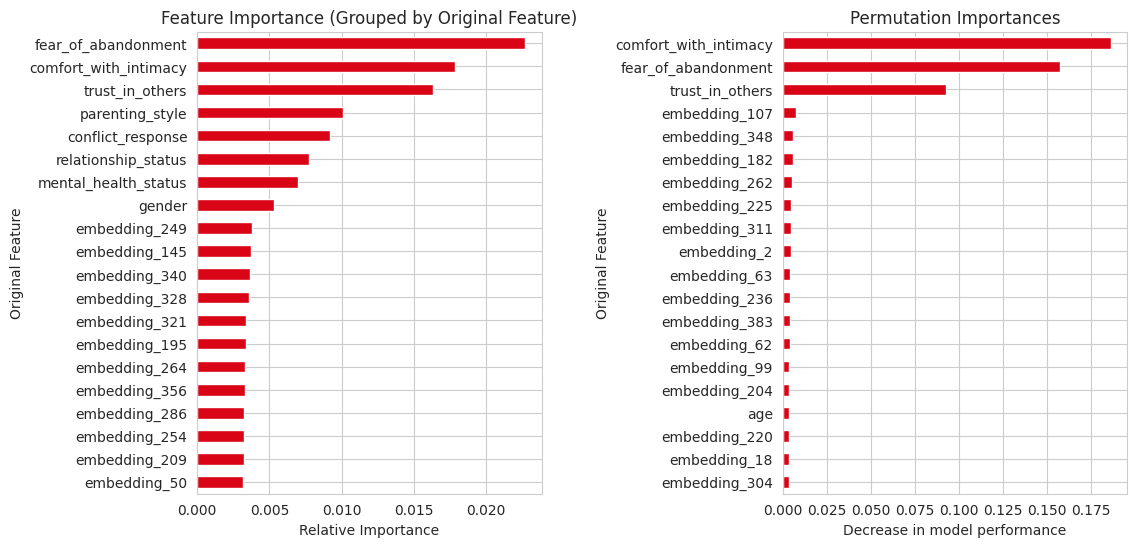

In [74]:
#plot the charts
#the XGB feature importance chart shows normalised importance scores. They sum to 1 across all features
#the permutation chart shows the absolute drop in model score when the feature is shuffled, e.g if model performance drops by 0.22 
#this means 22 percentage points when this feature is shuffled. Any negative permutation features show shuffling the feature slightly 
#improved performance → i.e. the feature is noise / redundant

top_n = 20

top_features = grouped_importance.head(top_n)
top_features_perm = perm_importance.head(top_n)

plt.figure(figsize = (12, 6))

#plot model feature importance
ax = plt.subplot(1, 2, 1)
top_features.set_index('original_feature')['importance'].plot(kind = 'barh', color = '#D90416')
plt.gca().invert_yaxis()
plt.xlabel('Relative Importance')
plt.ylabel('Original Feature')
plt.title('Feature Importance (Grouped by Original Feature)')

#plot permutation feature importance
ax = plt.subplot(1, 2, 2)
top_features_perm.set_index('feature')['importance_mean'].plot(kind = 'barh', color = '#D90416')

plt.gca().invert_yaxis()
plt.xlabel('Decrease in model performance')
plt.ylabel('Original Feature')
plt.title('Permutation Importances')

plt.subplots_adjust(wspace = 0.7)

plt.show()

In [75]:
#check how important embeddings were versus structured features
structured_features = feature_importance_df[~feature_importance_df['feature'].str.contains('embedding')]
embedding_features = feature_importance_df[feature_importance_df['feature'].str.contains('embedding')]

print('Total importance (structured): ', structured_features['importance'].sum())
print('Total importance (embeddings): ', embedding_features['importance'].sum())

Total importance (structured):  0.1042702
Total importance (embeddings):  0.8957298


In [76]:
#will draw out the final confusion matrix for slide deck - first get the data labels

best_matrix = confusion_matrix(y_test, y_pred_best)

#flatten puts the array values into one row
counts = ['{:,}'.format(value) for value in best_matrix.flatten()]
percentages = ['{0:.1%}'.format(value) for value in best_matrix.flatten() / np.sum(best_matrix)]

#the below attaches the above information together
labels = [f'{a} \n {b}' for a, b, in zip(counts, percentages)]

#converting the above into an array
labels_array = np.asarray(labels).reshape(4, 4)

In [77]:
#stats to display below the matrix

#overall / macro metrics for multiclass model
accuracy = np.trace(best_matrix) / np.sum(best_matrix)

precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred_best, average = 'macro')

text = (
    '\n\nAccuracy = {:0.3f}'
    '\nMacro precision = {:0.3f}'
    '\nMacro recall = {:0.3f}'
    '\nMacro F1 score = {:0.3f}'
).format(accuracy, precision, recall, f1_score)

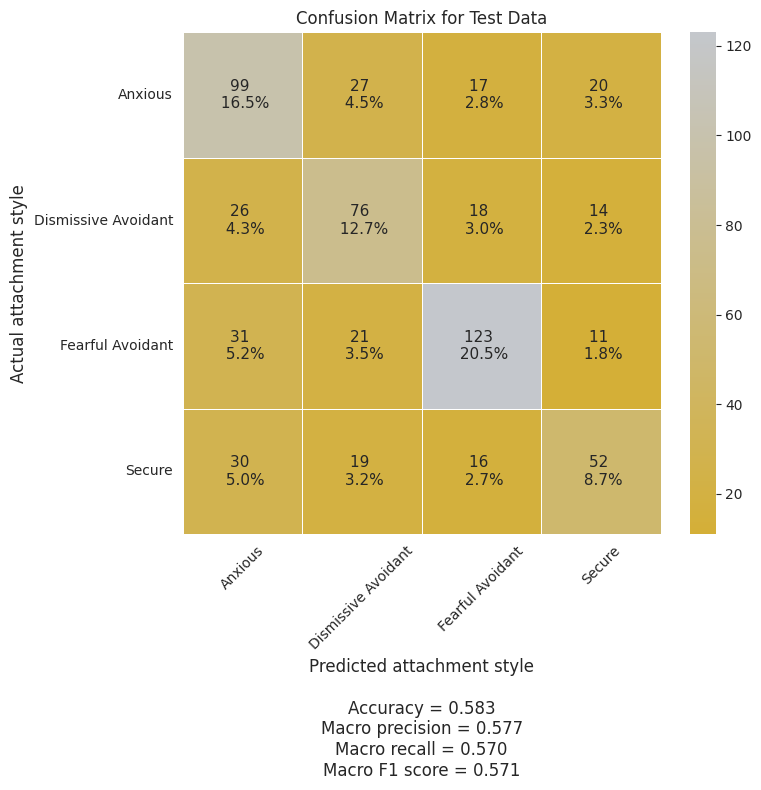

In [78]:
# class labels
class_labels = ['Anxious', 'Dismissive Avoidant', 'Fearful Avoidant', 'Secure']

#create plot
fig = plt.figure(figsize = (8, 8))
ax = plt.subplot()

matrix_colours = ['#D4AF37', '#C4C7CC']
matrix_cmap = LinearSegmentedColormap.from_list('Custom', matrix_colours, N = 256)

sns.heatmap(best_matrix, annot = labels_array, fmt = '', cmap = matrix_cmap, cbar = True, linewidths = 0.5, linecolor = 'white',\
annot_kws = {'size': 11})

ax.set_xlabel('Predicted attachment style' + text, fontsize = 12)
ax.set_ylabel('Actual attachment style', fontsize = 12)

ax.set_xticklabels(class_labels, rotation = 45)
ax.set_yticklabels(class_labels, rotation = 0)

ax.set_title('Confusion Matrix for Test Data', fontsize = 12)

plt.tight_layout()
plt.show()

# Insights From Final Model

**The tuned XGBoost model demonstrates stable generalisation to the test set, with performance broadly in line with validation expectations. The model achieved an accuracy of 58% and a macro F1 score of 57% on unseen data, indicating no evidence of overfitting. The multiclass AUC of 0.84 further supports this, showing that the model retains strong class separability when applied to new data.**

**At a class level, performance remains uneven but consistent with earlier patterns. Fearful Avoidant (class 2) continues to generalise best, achieving the highest precision (0.71) and F1 score (0.68), suggesting that the model has learned stable and transferable patterns for this class. In contrast, Secure (class 3) shows weaker generalisation, with recall at 0.44, indicating that the model struggles to correctly identify secure profiles and frequently misclassifies them as other attachment styles.**

**Feature importance analysis reveals a clear pattern: core psychological variables dominate model performance. Features such as comfort with intimacy, fear of abandonment, and trust in others are consistently the most important across both model-based and permutation importance methods. These features also show the largest drops in performance when shuffled, confirming that they are genuine drivers of prediction rather than artefacts of model structure.**

**Although embeddings account for a large proportion of total feature importance (approximately 90% when aggregated), their individual contribution is weak and highly fragmented. In contrast, structured features are fewer in number but have substantially stronger individual impact. This suggests that embeddings contribute marginal signal in aggregate but do not provide meaningful or interpretable predictive structure.**

**The alignment between test performance and validation results indicates that hyperparameter tuning has improved model robustness rather than fitting noise, with no observable degradation in performance on unseen data.**

**Overall, the tuned XGBoost model shows good generalisation capability, with incremental improvements over earlier models preserved on the test set. However, the relatively modest gains and continued difficulty in predicting certain classes suggest that performance is now primarily constrained by feature representation rather than model choice or further tuning.**

In [80]:
#save relevant data
model_artifacts = {
    'model': best_xgb,
    'structured_preprocessor': structured_preprocessor,
    'feature_columns': X_train_combined.columns.tolist(),
    'embedding_model_name': 'sentence-transformers/all-MiniLM-L6-v2',
    'embedding_columns': embedding_columns,
    'text_col': 'relationship_reflection',
    'id_col': '__row_id',
    'label_map': label_map
}

with open('attachment_style_model_artifacts.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)